<a href="https://colab.research.google.com/github/pamritha25/ML-and-DL-Projects/blob/main/Student%20performance/student_performence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem statement**

Educational institutions often face challenges in identifying students at different levels of academic performance early enough to provide timely support. Traditional evaluation methods primarily focus on final examination scores, which may not effectively capture overall student engagement and behavioral factors influencing performance.

This project aims to develop a multi-class classification machine learning model that predicts student performance levels (such as Excellent, Good, Average, Below Average, and Poor) using historical academic records and behavioral attributes including attendance, study hours, and class participation.

By categorizing students into multiple performance levels rather than a simple binary classification (well/poor), the model provides more detailed insights, enabling educators to implement targeted interventions and personalized support strategies to enhance academic outcomes

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/Student performance data.csv")


In [ ]:
df.head(10)

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade,performance_status
0,1,7,100,10,82.46,A,Good
1,2,20,74,2,69.35,C,Average
2,3,29,90,3,100.00,A+,Excellent
3,4,15,93,3,71.20,B,Average
4,5,11,76,4,68.98,C,Average
5,6,8,61,9,65.85,C,Average
6,7,29,91,6,100.00,A+,Excellent
7,8,21,71,8,92.29,A+,Excellent
8,9,7,97,2,66.56,C,Average
9,10,26,73,7,92.33,A+,Excellent


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               300000 non-null  int64  
 1   weekly_self_study_hours  300000 non-null  int64  
 2   attendance_percentage    300000 non-null  int64  
 3   class_participation      300000 non-null  int64  
 4   total_score              300000 non-null  float64
 5   grade                    300000 non-null  object 
 6   performance_status       300000 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 16.0+ MB


In [ ]:
df.duplicated().sum()

np.int64(0)

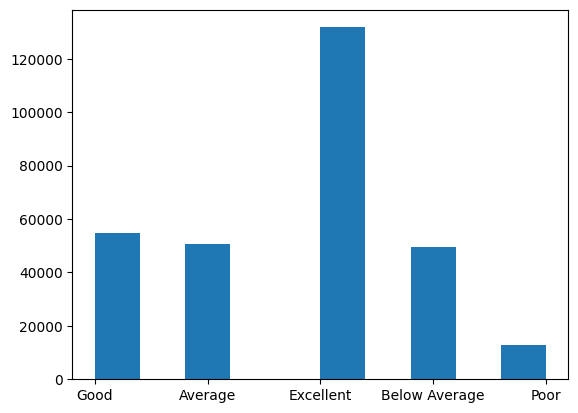

In [ ]:
plt.hist(df["performance_status"])
plt.show()

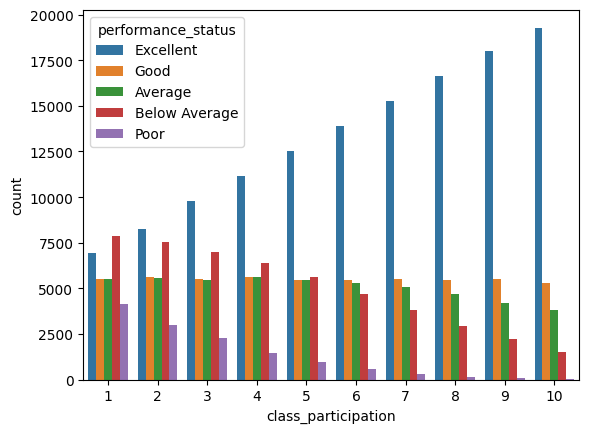

In [ ]:
sns.countplot(data=df, x="class_participation", hue='performance_status')
plt.show()

<Axes: xlabel='weekly_self_study_hours', ylabel='grade'>

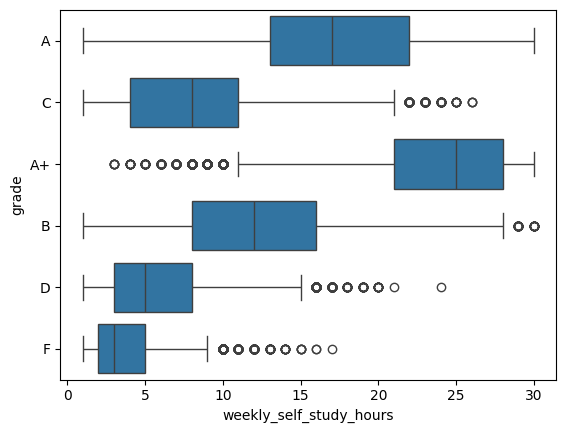

In [ ]:
sns.boxplot(x='weekly_self_study_hours', y='grade', data=df)

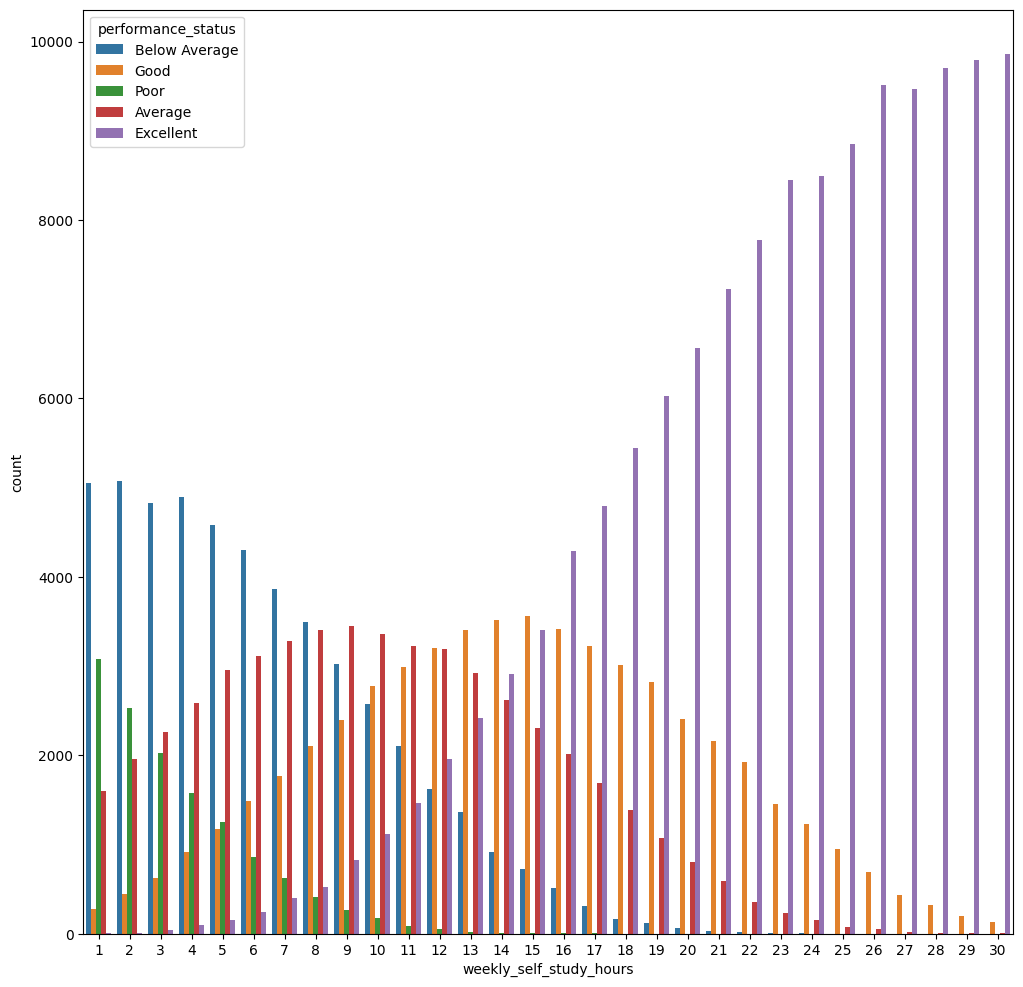

In [ ]:
plt.figure(figsize=(12,12))
sns.countplot(data=df, x='weekly_self_study_hours', hue='performance_status')
plt.show()

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               300000 non-null  int64  
 1   weekly_self_study_hours  300000 non-null  int64  
 2   attendance_percentage    300000 non-null  int64  
 3   class_participation      300000 non-null  int64  
 4   total_score              300000 non-null  float64
 5   grade                    300000 non-null  object 
 6   performance_status       300000 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 16.0+ MB


In [ ]:
print(df["performance_status"].unique())

['Good' 'Average' 'Excellent' 'Below Average' 'Poor']


In [ ]:
df["performance_status"].replace(['Poor','Below Average','Average', 'Good','Excellent'],[0,1,2,3,4],inplace=True)

/tmp/ipython-input-307/2690436585.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["performance_status"].replace(['Poor','Below Average','Average', 'Good','Excellent'],[0,1,2,3,4],inplace=True)
/tmp/ipython-input-307/2690436585.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["performanc

In [ ]:
print(df["grade"].unique())

['A' 'C' 'A+' 'B' 'D' 'F']


In [ ]:
df["grade"].replace(['F', 'D', 'C', 'B', 'A', 'A+'],[0,1,2,3,4,5],inplace=True)

/tmp/ipython-input-307/1893676831.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["grade"].replace(['F', 'D', 'C', 'B', 'A', 'A+'],[0,1,2,3,4,5],inplace=True)
/tmp/ipython-input-307/1893676831.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["grade"].replace(['F', 'D', 'C', 'B', 'A', 'A

In [ ]:
df

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade,performance_status
0,1,7,100,10,82.46,4,3
1,2,20,74,2,69.35,2,2
2,3,29,90,3,100.00,5,4
3,4,15,93,3,71.20,3,2
4,5,11,76,4,68.98,2,2
...,...,...,...,...,...,...,...
299995,299996,2,82,10,66.39,2,2
299996,299997,21,74,3,85.54,4,4
299997,299998,30,84,5,100.00,5,4
299998,299999,13,76,10,91.16,5,4


In [ ]:
df.isnull().sum()

,0
student_id,0
weekly_self_study_hours,0
attendance_percentage,0
class_participation,0
total_score,0
grade,0
performance_status,0


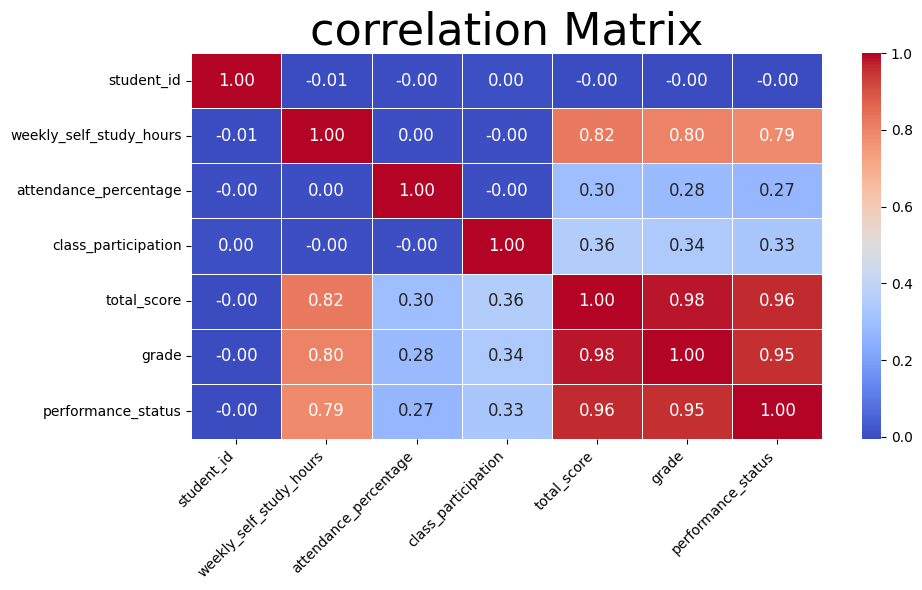

In [ ]:
plt.figure(figsize=(10,6))
corr_matrix=df.corr(numeric_only=True)
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5,annot_kws={"size":12})
plt.title("correlation Matrix",fontsize=32)
plt.xticks(rotation=45,ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
df.drop(["grade","total_score"],axis=1,inplace=True, errors='ignore')

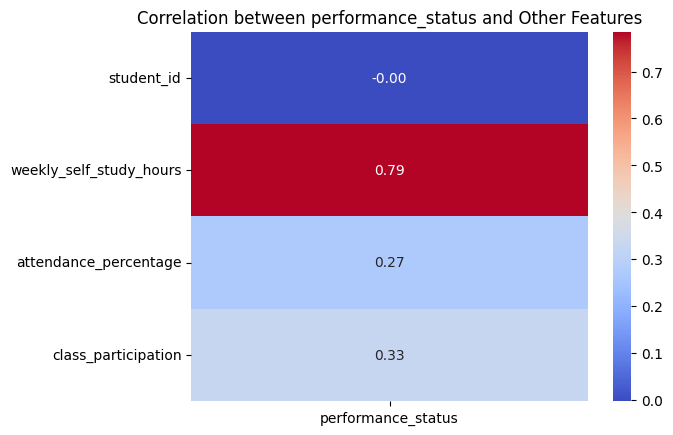

In [ ]:

performance_status_corr = df.corr(numeric_only=True)['performance_status']


performance_status_corr = performance_status_corr.drop('performance_status')


sns.heatmap(performance_status_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})
plt.title('Correlation between performance_status and Other Features')
plt.show()

In [ ]:
df.drop(["student_id"],axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 4 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   weekly_self_study_hours  300000 non-null  int64
 1   attendance_percentage    300000 non-null  int64
 2   class_participation      300000 non-null  int64
 3   performance_status       300000 non-null  int64
dtypes: int64(4)
memory usage: 9.2 MB


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler



features = ["weekly_self_study_hours","attendance_percentage", "class_participation"]

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[features])

scaled_df = pd.DataFrame(scaled_data, columns=features)

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd


X = df[["weekly_self_study_hours","attendance_percentage", "class_participation"]]


y = df[["performance_status"]]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


model = LogisticRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Baseline model accuracy: 0.57


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
model.predict([[11,76,4]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([2])

In [ ]:
df.head(20)

,weekly_self_study_hours,attendance_percentage,class_participation,performance_status
0,7,100,10,3
1,20,74,2,2
2,29,90,3,4
3,15,93,3,2
4,11,76,4,2
5,8,61,9,2
6,29,91,6,4
7,21,71,8,4
8,7,97,2,2
9,26,73,7,4


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.76


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler

In [ ]:
pipeline = Pipeline([("scalar", StandardScaler()), ("model", LinearSVC(random_state=42, max_iter=5000))])
pipeline.fit(X_train, y_train.values.ravel())
y_pred = pipeline.predict(X_test)
print("accuracy:", accuracy_score(y_test, y_pred))

accuracy: 0.68312


In [ ]:
from sklearn.ensemble import RandomForestClassifier
model =RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Baseline model accuracy: 0.76


In [ ]:
from sklearn.model_selection import KFold
kf=KFold(n_splits=8,shuffle=True,random_state=42)
model=LogisticRegression()

In [ ]:
best_accuracy = 0
best_fold = -1
best_X_train = None
best_y_train = None
best_X_test = None
best_y_test = None
best_y_pred = None
for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Fold {fold} Accuracy: {acc}")

    if acc > best_accuracy:
        best_accuracy = acc
        best_fold = fold
        best_X_train = X_train
        best_y_train = y_train
        best_X_test = X_test
        best_y_test = y_test
        best_y_pred = y_pred
print(f"\n Best Fold: {best_fold} with Accuracy: {best_accuracy}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel

Fold 1 Accuracy: 0.56816


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Fold 2 Accuracy: 0.5668533333333333


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Fold 6 Accuracy: 0.56208


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Fold 7 Accuracy: 0.56592
Fold 8 Accuracy: 0.5665066666666667

 Best Fold: 5 with Accuracy: 0.5686666666666667


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
model = LogisticRegression()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.5686666666666667

In [ ]:
model=DecisionTreeClassifier()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.7630133333333333

In [ ]:
model=RandomForestClassifier()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.7632

dl

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import sparse_categorical_crossentropy
from tensorflow.keras.metrics import Accuracy

In [ ]:
model=Sequential()
model.add(Dense(128,input_shape=(3,),activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(5,activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 4 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   weekly_self_study_hours  300000 non-null  int64
 1   attendance_percentage    300000 non-null  int64
 2   class_participation      300000 non-null  int64
 3   performance_status       300000 non-null  int64
dtypes: int64(4)
memory usage: 9.2 MB


In [ ]:
print(df['performance_status'].unique())

[3 2 4 1 0]


In [ ]:
model.fit(best_X_train,best_y_train,epochs=100, batch_size=32)

Epoch 1/100
8204/8204 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.7692 - loss: 0.5153
Epoch 2/100
8204/8204 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.7675 - loss: 0.5171
Epoch 3/100
8204/8204 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.7679 - loss: 0.5162
Epoch 4/100
8204/8204 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.7680 - loss: 0.5164
Epoch 5/100
8204/8204 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.7703 - loss: 0.5122
Epoch 6/100
8204/8204 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.7691 - loss: 0.5156
Epoch 7/100
8204/8204 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - accuracy: 0.7694 - loss: 0.5142
Epoch 8/100
8204/8204 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.7692 - loss: 0.5133
Epoch 9/100
8204/8204 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.7687 - loss: 0.5148
Epoch 10/100
8204/8204 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - accuracy: 0.7688 - loss: 0.5151
Epoch 11/100
8204/8204 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.7696 - loss: 0.5134
Epoch 12

In [ ]:
loss,accuracy=model.evaluate(best_X_test,best_y_test)
print(f'model accuracy:{accuracy*100:.2f}%')

1172/1172 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7713 - loss: 0.5137
model accuracy:77.18%


In [ ]:
import pickle
with open("student dl model.pkl","wb") as file:
  pickle.dump(model,file)

In [ ]:
with open("/content/student dl model.pkl","rb") as file:
  load_model=pickle.load(file)

# **Conclusion**

This project successfully demonstrates the application of machine learning techniques to predict student academic performance using historical academic and behavioral data. By formulating the task as a multi-class classification problem, the model categorizes students into multiple performance levels—Excellent, Good, Average, Below Average, and Poor—providing a more comprehensive understanding of student achievement compared to traditional binary evaluation methods.

The findings highlight that factors such as attendance, study hours, and class participation play a significant role in determining academic outcomes. The developed model enables early identification of students at varying performance levels, allowing educational institutions to implement timely interventions and personalized support strategies.

Overall, this study reinforces the potential of data-driven approaches in enhancing educational decision-making. With further refinement, larger datasets, and integration into institutional systems, the proposed model can serve as an effective tool for improving student success rates and promoting proactive academic support.